# Cluster Interpretation & Labeling System
## User Segmentation Analysis

This notebook analyzes the KMeans clustering results and creates a consistent labeling system for user segments based on behavioral features.

### Key Features:
- **Semantic Labeling**: Clusters labeled based on engagement and purchase behavior
- **Balanced Distribution**: A/B/C/D codes assigned using quartile ranking (targets ~25% per tier)
- **Multiple Clusters Per Code**: Clusters with similar value can share the same code
- **Temporal Tracking**: Run on multiple months to track user segment evolution

### Setup & Data Loading

In [47]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

# Connect to DuckDB
DB_NAME = Path("/home/c-enjalbert/Documents/Github/MSPR/bloc_2/amazing/amazing.duckdb")
con = duckdb.connect(str(DB_NAME))

TABLE_SEGMENTS = "user_segments_11_2019_kmeans"

print(f"Connected to {DB_NAME}")
print(f"Loading table: {TABLE_SEGMENTS}")
print("\n" + "="*100)
print("💡 USAGE INSTRUCTIONS")
print("="*100)
print("To analyze different months, simply change TABLE_SEGMENTS variable above:")
print("  • user_segments_10_2019_kmeans  (October 2019)")
print("  • user_segments_11_2019_kmeans  (November 2019)")
print("  • user_segments_12_2019_kmeans  (December 2019)")
print("  • user_segments_01_2020_kmeans  (January 2020)")
print("  • etc.")
print("\nEach run will add a new column to the 'user_profiles' table.")
print("="*100 + "\n")

Connected to /home/c-enjalbert/Documents/Github/MSPR/bloc_2/amazing/amazing.duckdb
Loading table: user_segments_11_2019_kmeans

💡 USAGE INSTRUCTIONS
To analyze different months, simply change TABLE_SEGMENTS variable above:
  • user_segments_10_2019_kmeans  (October 2019)
  • user_segments_11_2019_kmeans  (November 2019)
  • user_segments_12_2019_kmeans  (December 2019)
  • user_segments_01_2020_kmeans  (January 2020)
  • etc.

Each run will add a new column to the 'user_profiles' table.



In [48]:
# Load the data
query = f"SELECT * FROM {TABLE_SEGMENTS}"
df_segments = con.execute(query).df()

print(f"Shape: {df_segments.shape}")
print(f"\nColumn: {df_segments.columns.tolist()}")
print(f"\nData types:\n{df_segments.dtypes}")
print(f"\nFirst few rows:")
df_segments.head(10)

Shape: (300000, 8)

Column: ['user_id', 'total_events', 'total_views', 'total_purchases', 'total_spent', 'avg_basket', 'last_event_time', 'segment']

Data types:
user_id                    object
total_events                int64
total_views               float64
total_purchases           float64
total_spent               float64
avg_basket                float64
last_event_time    datetime64[us]
segment                     int32
dtype: object

First few rows:


,user_id,total_events,total_views,total_purchases,total_spent,avg_basket,last_event_time,segment
0,524323265,15,14.0,0.0,0.00,0.00,2019-11-25 10:46:39,1
1,514466368,35,28.0,2.0,83.82,41.91,2019-11-22 04:03:03,1
2,516712520,20,19.0,0.0,0.00,0.00,2019-11-16 08:13:12,1
3,572665715,42,39.0,1.0,87.52,87.52,2019-11-29 06:04:29,1
4,573296873,16,16.0,0.0,0.00,0.00,2019-11-30 05:00:46,1
5,513360974,17,17.0,0.0,0.00,0.00,2019-11-13 12:01:04,1
6,526866237,19,19.0,0.0,0.00,0.00,2019-11-29 13:16:55,1
7,524523234,22,18.0,1.0,36.81,36.81,2019-11-24 06:03:34,1
8,566061975,27,10.0,2.0,176.56,88.28,2019-11-04 16:18:04,1
9,537154073,36,36.0,0.0,0.00,0.00,2019-11-07 17:36:32,1


### Cluster Profile Analysis

Calculate mean features for each cluster to understand their characteristics.

In [49]:
# Group by segment and calculate mean values
cluster_profiles = df_segments.groupby('segment').agg({
    'total_events': ['count', 'mean', 'min', 'max', 'std'],
    'total_views': ['mean', 'min', 'max'],
    'total_purchases': ['mean', 'min', 'max'],
    'total_spent': ['mean', 'min', 'max'],
    'avg_basket': ['mean', 'min', 'max'],
}).round(2)

print("=" * 100)
print("CLUSTER PROFILES - Aggregated Statistics")
print("=" * 100)
print(cluster_profiles)

CLUSTER PROFILES - Aggregated Statistics
        total_events                                 total_views           \
               count      mean    min    max     std        mean      min   
segment                                                                     
0              29561    119.14     10   4771  148.81      109.20      1.0   
1             269612     35.33     10    263   33.28       33.66      0.0   
2                  1  22929.00  22929  22929     NaN    22926.00  22926.0   
3                826    204.75     29   1957  193.15      142.38     12.0   

                 total_purchases             total_spent                     \
             max            mean  min    max        mean     min        max   
segment                                                                       
0         4769.0            2.90  0.0   25.0     1171.55    0.00    9227.17   
1          249.0            0.28  0.0    8.0       35.56    0.00     988.22   
2        22926.0        

In [50]:
# Cleaner view: mean values by cluster
cluster_means = df_segments.groupby('segment')[[
    'total_events', 'total_views', 'total_purchases', 'total_spent', 'avg_basket'
]].mean().round(2)

# Add cluster size
cluster_means['cluster_size'] = df_segments.groupby('segment').size()
cluster_means['pct_of_total'] = (cluster_means['cluster_size'] / len(df_segments) * 100).round(1)

# Reorder columns
cluster_means = cluster_means[['cluster_size', 'pct_of_total', 'total_events', 'total_views', 
                                'total_purchases', 'total_spent', 'avg_basket']]

print("\n" + "=" * 120)
print("CLUSTER PROFILES - Mean Features")
print("=" * 120)
print(cluster_means)
print("\n")


CLUSTER PROFILES - Mean Features
         cluster_size  pct_of_total  total_events  total_views  \
segment                                                          
0               29561           9.9        119.14       109.20   
1              269612          89.9         35.33        33.66   
2                   1           0.0      22929.00     22926.00   
3                 826           0.3        204.75       142.38   

         total_purchases  total_spent  avg_basket  
segment                                            
0                   2.90      1171.55      479.73  
1                   0.28        35.56       24.11  
2                   0.00         0.00        0.00  
3                  24.54     11476.40      579.59  




In [51]:
# Calculate key metrics for characterization
metrics = df_segments.groupby('segment').agg({
    'total_purchases': lambda x: (x > 0).sum() / len(x),  # Conversion rate
    'total_spent': lambda x: (x > 0).sum() / len(x),      # Buyer rate
    'total_views': 'mean',
    'total_events': 'mean',
    'avg_basket': lambda x: x[x > 0].mean() if (x > 0).any() else 0  # Avg basket for buyers only
}).round(2)

metrics.columns = ['conversion_rate', 'buyer_rate', 'avg_views', 'avg_events', 'avg_basket_buyers']
metrics = metrics.round(3)

print("\n" + "=" * 100)
print("BEHAVIORAL METRICS")
print("=" * 100)
print(metrics)
print("\n")


BEHAVIORAL METRICS
         conversion_rate  buyer_rate  avg_views  avg_events  avg_basket_buyers
segment                                                                       
0                   0.94        0.94     109.20      119.14             511.17
1                   0.18        0.18      33.66       35.33             132.16
2                   0.00        0.00   22926.00    22929.00               0.00
3                   1.00        1.00     142.38      204.75             579.59




### Cluster Characterization & Labeling

In [52]:
# Define cluster labels based on characteristics
# This system is designed to be stable even if cluster numbers change

print("\n" + "=" * 100)
print("CLUSTER INTERPRETATION")
print("=" * 100)

cluster_labels = {}
interpretations = {}

for cluster_id in sorted(df_segments['segment'].unique()):
    cluster_data = cluster_means.loc[cluster_id]
    cluster_metrics = metrics.loc[cluster_id]
    
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id} - Size: {int(cluster_data['cluster_size'])} users ({cluster_data['pct_of_total']}%)")
    print(f"{'='*80}")
    
    # Key characteristics
    print(f"\nBehavioral Characteristics:")
    print(f"  • Average Events: {cluster_data['total_events']:.1f}")
    print(f"  • Average Views: {cluster_data['total_views']:.1f}")
    print(f"  • Average Purchases: {cluster_data['total_purchases']:.2f}")
    print(f"  • Conversion Rate: {cluster_metrics['conversion_rate']*100:.1f}%")
    print(f"  • Buyer Rate: {cluster_metrics['buyer_rate']*100:.1f}%")
    print(f"  • Total Spent (mean): ${cluster_data['total_spent']:.2f}")
    print(f"  • Avg Basket Value: ${cluster_data['avg_basket']:.2f}")
    
    # Determine label based on engagement and purchase behavior
    engagement_level = cluster_data['total_events']
    purchase_rate = cluster_metrics['buyer_rate']
    basket_value = cluster_data['avg_basket']
    
    # Categorization logic
    if engagement_level < 20:  # Low engagement
        if purchase_rate < 0.1:  
            label = "Window Shoppers"
            description = "Low engagement, minimal purchases - exploratory users"
        else:
            label = "Occasional Buyers"
            description = "Low engagement but willing to buy occasionally"
    elif engagement_level < 50:  # Medium engagement
        if purchase_rate < 0.1:
            label = "Active Browsers"
            description = "Medium engagement, research-oriented, few purchases"
        else:
            label = "Regular Customers"
            description = "Medium engagement with consistent purchase behavior"
    else:  # High engagement
        if basket_value > 100:
            label = "High-Value Customers"
            description = "High engagement with premium spending patterns"
        else:
            label = "Power Users"
            description = "Very high engagement but moderate spending"
    
    cluster_labels[cluster_id] = label
    interpretations[cluster_id] = {
        'label': label,
        'description': description,
        'size': int(cluster_data['cluster_size']),
        'pct_of_total': float(cluster_data['pct_of_total']),
        'engagement': float(cluster_data['total_events']),
        'conversion_rate': float(cluster_metrics['conversion_rate']),
        'buyer_rate': float(cluster_metrics['buyer_rate']),
        'avg_spent': float(cluster_data['total_spent']),
        'avg_basket': float(cluster_data['avg_basket'])
    }
    
    print(f"\n✓ Label: {label}")
    print(f"  Description: {description}")
    print()


CLUSTER INTERPRETATION

CLUSTER 0 - Size: 29561 users (9.9%)

Behavioral Characteristics:
  • Average Events: 119.1
  • Average Views: 109.2
  • Average Purchases: 2.90
  • Conversion Rate: 94.0%
  • Buyer Rate: 94.0%
  • Total Spent (mean): $1171.55
  • Avg Basket Value: $479.73

✓ Label: High-Value Customers
  Description: High engagement with premium spending patterns


CLUSTER 1 - Size: 269612 users (89.9%)

Behavioral Characteristics:
  • Average Events: 35.3
  • Average Views: 33.7
  • Average Purchases: 0.28
  • Conversion Rate: 18.0%
  • Buyer Rate: 18.0%
  • Total Spent (mean): $35.56
  • Avg Basket Value: $24.11

✓ Label: Regular Customers
  Description: Medium engagement with consistent purchase behavior


CLUSTER 2 - Size: 1 users (0.0%)

Behavioral Characteristics:
  • Average Events: 22929.0
  • Average Views: 22926.0
  • Average Purchases: 0.00
  • Conversion Rate: 0.0%
  • Buyer Rate: 0.0%
  • Total Spent (mean): $0.00
  • Avg Basket Value: $0.00

✓ Label: Power Users


### Summary Table of Cluster Labels

In [53]:
# Create summary DataFrame
summary_data = []
for cluster_id, interp in interpretations.items():
    summary_data.append({
        'Cluster_ID': cluster_id,
        'Label': interp['label'],
        'Size': interp['size'],
        '% of Total': interp['pct_of_total'],
        'Avg Events': interp['engagement'],
        'Conversion Rate': f"{interp['conversion_rate']*100:.1f}%",
        'Buyer Rate': f"{interp['buyer_rate']*100:.1f}%",
        'Avg Spent ($)': f"{interp['avg_spent']:.2f}",
        'Avg Basket ($)': f"{interp['avg_basket']:.2f}"
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*140)
print("FINAL CLUSTER LABELS & SUMMARY")
print("="*140)
print(summary_df.to_string(index=False))
print("\n")


FINAL CLUSTER LABELS & SUMMARY
 Cluster_ID                Label   Size  % of Total  Avg Events Conversion Rate Buyer Rate Avg Spent ($) Avg Basket ($)
          0 High-Value Customers  29561         9.9      119.14           94.0%      94.0%       1171.55         479.73
          1    Regular Customers 269612        89.9       35.33           18.0%      18.0%         35.56          24.11
          2          Power Users      1         0.0    22929.00            0.0%       0.0%          0.00           0.00
          3 High-Value Customers    826         0.3      204.75          100.0%     100.0%      11476.40         579.59




### Visualization: Cluster Profiles Comparison

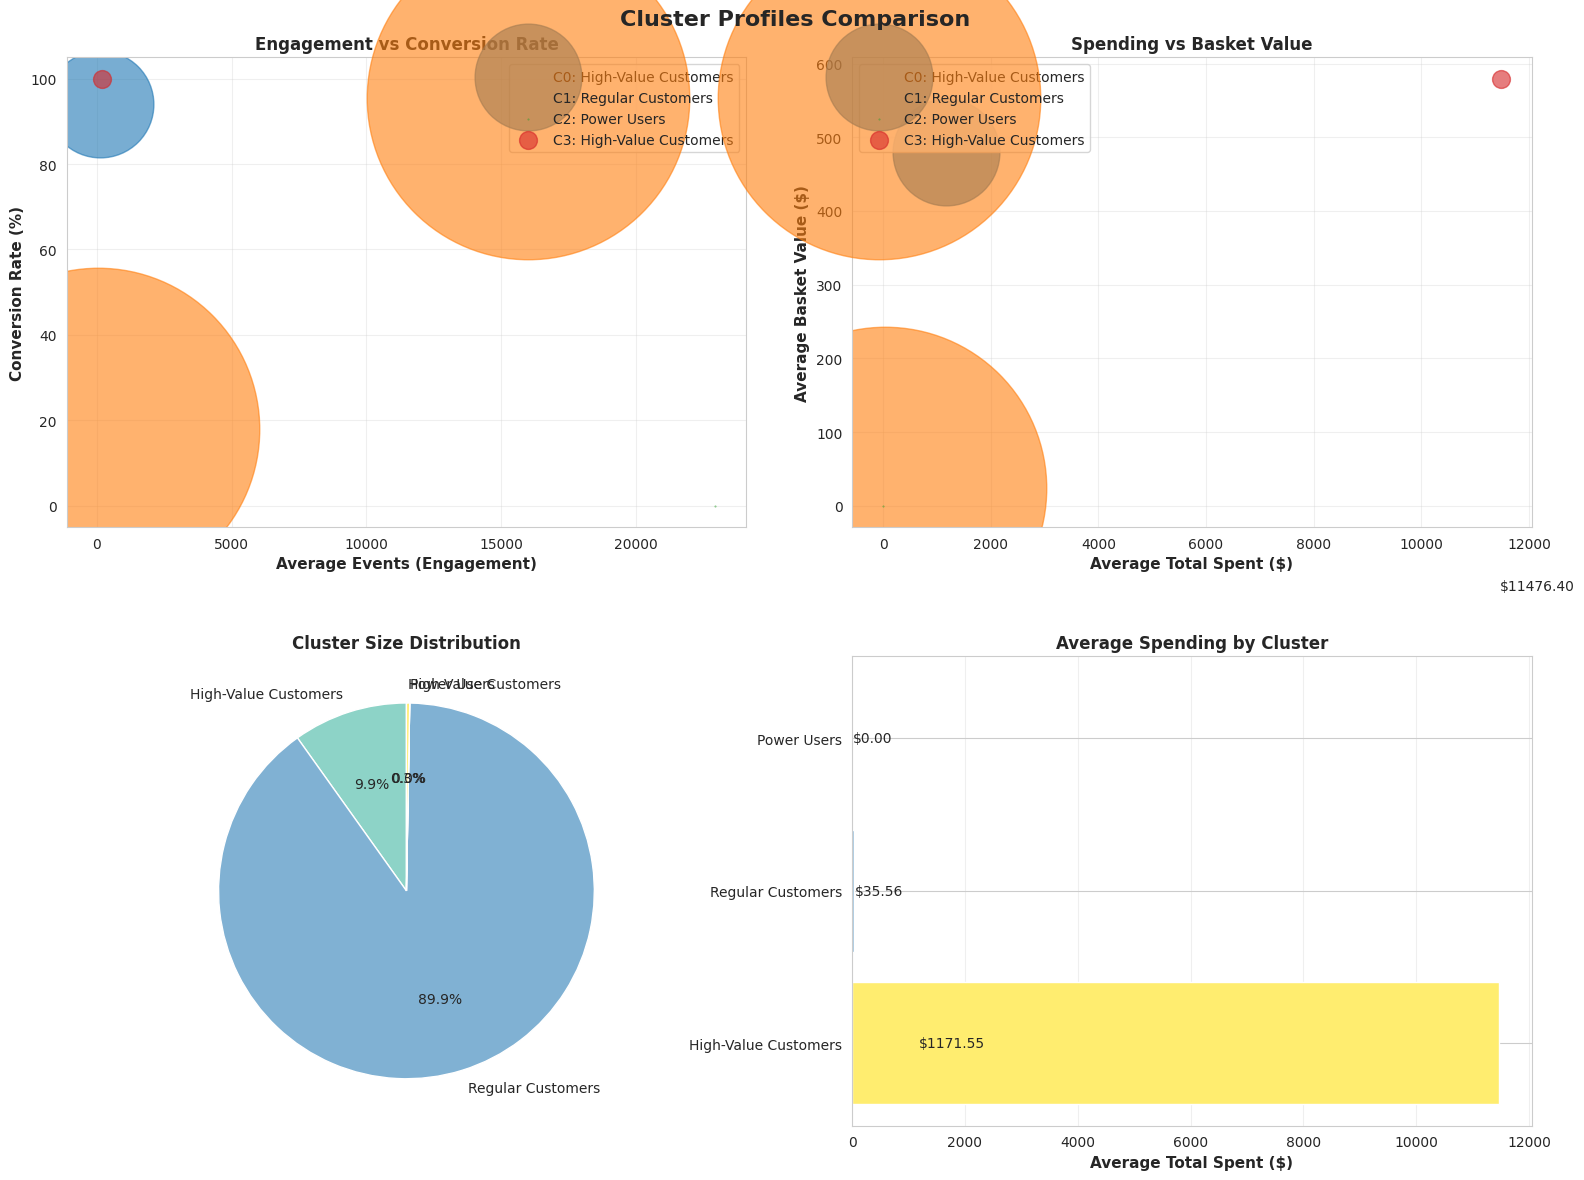

✓ Visualizations created successfully


In [54]:
# Prepare data for visualization
cluster_names = [f"C{k}: {cluster_labels[k]}" for k in sorted(cluster_labels.keys())]

# Create radar chart-like comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cluster Profiles Comparison', fontsize=16, fontweight='bold')

# 1. Engagement vs Conversion
ax1 = axes[0, 0]
for cluster_id in sorted(df_segments['segment'].unique()):
    ax1.scatter(cluster_means.loc[cluster_id, 'total_events'],
               metrics.loc[cluster_id, 'conversion_rate'] * 100,
               s=cluster_means.loc[cluster_id, 'cluster_size'] / 5,
               label=f"C{cluster_id}: {cluster_labels[cluster_id]}",
               alpha=0.6)
ax1.set_xlabel('Average Events (Engagement)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Conversion Rate (%)', fontsize=11, fontweight='bold')
ax1.set_title('Engagement vs Conversion Rate', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Spending vs Basket Value
ax2 = axes[0, 1]
for cluster_id in sorted(df_segments['segment'].unique()):
    ax2.scatter(cluster_means.loc[cluster_id, 'total_spent'],
               cluster_means.loc[cluster_id, 'avg_basket'],
               s=cluster_means.loc[cluster_id, 'cluster_size'] / 5,
               label=f"C{cluster_id}: {cluster_labels[cluster_id]}",
               alpha=0.6)
ax2.set_xlabel('Average Total Spent ($)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Average Basket Value ($)', fontsize=11, fontweight='bold')
ax2.set_title('Spending vs Basket Value', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Cluster Size
ax3 = axes[1, 0]
cluster_ids = sorted(cluster_labels.keys())
labels_for_chart = [cluster_labels[cid] for cid in cluster_ids]
sizes = [cluster_means.loc[cid, 'cluster_size'] for cid in cluster_ids]
colors = plt.cm.Set3(np.linspace(0, 1, len(cluster_ids)))
pie = ax3.pie(sizes, labels=labels_for_chart, autopct='%1.1f%%', colors=colors, startangle=90)
ax3.set_title('Cluster Size Distribution', fontweight='bold')

# 4. Average Spent by Cluster
ax4 = axes[1, 1]
avg_spent = [cluster_means.loc[cid, 'total_spent'] for cid in cluster_ids]
ax4.barh(labels_for_chart, avg_spent, color=colors)
ax4.set_xlabel('Average Total Spent ($)', fontsize=11, fontweight='bold')
ax4.set_title('Average Spending by Cluster', fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

for i, v in enumerate(avg_spent):
    ax4.text(v + 5, i, f'${v:.2f}', va='center')

plt.tight_layout()
plt.show()

print("✓ Visualizations created successfully")

### Labeling System & Mapping

Create a robust mapping system that remains consistent even if cluster numbers change.

In [55]:
# Create a feature-based mapping system
# This allows matching profiles even if cluster IDs change

def create_cluster_mapping(df, cluster_col='segment'):
    """
    Creates a mapping from cluster numbers to labels based on features.
    This is robust to cluster ID changes.
    """
    profiles = {}
    
    for cluster_id in sorted(df[cluster_col].unique()):
        cluster_data = df[df[cluster_col] == cluster_id]
        
        # Calculate profile signature
        profile = {
            'cluster_id': int(cluster_id),
            'size': len(cluster_data),
            'avg_events': float(cluster_data['total_events'].mean()),
            'avg_views': float(cluster_data['total_views'].mean()),
            'avg_purchases': float(cluster_data['total_purchases'].mean()),
            'avg_spent': float(cluster_data['total_spent'].mean()),
            'avg_basket': float(cluster_data['avg_basket'].mean()),
            'conversion_rate': float((cluster_data['total_purchases'] > 0).sum() / len(cluster_data)),
        }
        profiles[cluster_id] = profile
    
    return profiles

# Generate the mapping
cluster_mapping = create_cluster_mapping(df_segments)

print("\n" + "="*100)
print("CLUSTER MAPPING (Feature-Based Profile)")
print("="*100)

for cluster_id, profile in cluster_mapping.items():
    print(f"\nCluster {cluster_id}: {cluster_labels[cluster_id]}")
    for key, value in profile.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.2f}")
        else:
            print(f"  {key}: {value}")


CLUSTER MAPPING (Feature-Based Profile)

Cluster 0: High-Value Customers
  cluster_id: 0
  size: 29561
  avg_events: 119.14
  avg_views: 109.20
  avg_purchases: 2.90
  avg_spent: 1171.55
  avg_basket: 479.73
  conversion_rate: 0.94

Cluster 1: Regular Customers
  cluster_id: 1
  size: 269612
  avg_events: 35.33
  avg_views: 33.66
  avg_purchases: 0.28
  avg_spent: 35.56
  avg_basket: 24.11
  conversion_rate: 0.18

Cluster 2: Power Users
  cluster_id: 2
  size: 1
  avg_events: 22929.00
  avg_views: 22926.00
  avg_purchases: 0.00
  avg_spent: 0.00
  avg_basket: 0.00
  conversion_rate: 0.00

Cluster 3: High-Value Customers
  cluster_id: 3
  size: 826
  avg_events: 204.75
  avg_views: 142.38
  avg_purchases: 24.54
  avg_spent: 11476.40
  avg_basket: 579.59
  conversion_rate: 1.00


### Segment Labeling with Standardized Codes (A, B, C, D)

Map clusters to standardized codes using **balanced quartile distribution**:
- Clusters are ranked by a composite score (engagement, spending, conversion)
- Codes assigned to achieve roughly 25% of users per tier (A/B/C/D)
- Multiple clusters can share the same code if they fall in the same quartile
- Ensures balanced distribution even if one cluster dominates (e.g., 90% of users)

In [ ]:
# Map each cluster to a standardized code (A, B, C, D) with balanced distribution
# Uses composite scoring to rank clusters and assign codes to quartiles

print("\n" + "=" * 100)
print("SEGMENT CODES ASSIGNMENT (Balanced Distribution)")
print("=" * 100)

# Step 1: Calculate composite score for each cluster
cluster_scores = {}

print("\nStep 1: Calculating cluster scores...")
print(f"{'Cluster':<10} {'Size':<10} {'Engagement':<12} {'Spending':<12} {'Score':<10}")
print("-" * 60)

for cluster_id in sorted(cluster_labels.keys()):
    cluster_data = cluster_means.loc[cluster_id]
    cluster_met = metrics.loc[cluster_id]
    
    # Composite score: engagement + spending + conversion
    # Normalized to 0-100 scale for each component
    max_events = cluster_means['total_events'].max()
    max_spent = cluster_means['total_spent'].max()
    max_conversion = metrics['conversion_rate'].max()
    
    # Avoid division by zero
    engagement_score = (cluster_data['total_events'] / max_events * 100) if max_events > 0 else 0
    spending_score = (cluster_data['total_spent'] / max_spent * 100) if max_spent > 0 else 0
    conversion_score = (cluster_met['conversion_rate'] / max_conversion * 100) if max_conversion > 0 else 0
    
    # Weighted composite: engagement 40%, spending 40%, conversion 20%
    composite_score = (engagement_score * 0.4 + spending_score * 0.4 + conversion_score * 0.2)
    
    cluster_scores[cluster_id] = {
        'score': composite_score,
        'size': int(cluster_data['cluster_size']),
        'engagement': float(cluster_data['total_events']),
        'spending': float(cluster_data['total_spent'])
    }
    
    print(f"{cluster_id:<10} {cluster_scores[cluster_id]['size']:<10,} {cluster_scores[cluster_id]['engagement']:<12.1f} ${cluster_scores[cluster_id]['spending']:<11.2f} {composite_score:<10.1f}")

# Step 2: Rank clusters by score and assign to quartiles based on user distribution
print("\n\nStep 2: Assigning codes for balanced distribution...")

# Sort clusters by score (descending)
sorted_clusters = sorted(cluster_scores.items(), key=lambda x: x[1]['score'], reverse=True)

total_users = sum(score_data['size'] for _, score_data in sorted_clusters)
cumulative_users = 0
cluster_to_code = {}

# Assign codes to achieve roughly 25% per tier
# A: Top tier (0-25%)
# B: Second tier (25-50%)
# C: Third tier (50-75%)
# D: Bottom tier (75-100%)

for cluster_id, score_data in sorted_clusters:
    pct_before = (cumulative_users / total_users) * 100
    cumulative_users += score_data['size']
    pct_after = (cumulative_users / total_users) * 100
    
    # Assign code based on where the majority of this cluster's users fall
    pct_midpoint = (pct_before + pct_after) / 2
    
    if pct_midpoint < 25:
        code = "A"
    elif pct_midpoint < 50:
        code = "B"
    elif pct_midpoint < 75:
        code = "C"
    else:
        code = "D"
    
    cluster_to_code[cluster_id] = code

# Step 3: Display final assignments
print(f"\n{'Cluster ID':<12} {'Label':<30} {'Code':<6} {'Score':<8} {'Size':<10} {'Description'}")
print("-" * 110)

for cluster_id in sorted(cluster_labels.keys()):
    label = cluster_labels[cluster_id]
    code = cluster_to_code[cluster_id]
    score = cluster_scores[cluster_id]['score']
    size = cluster_scores[cluster_id]['size']
    description = interpretations[cluster_id]['description']
    
    print(f"{cluster_id:<12} {label:<30} {code:<6} {score:<8.1f} {size:<10,} {description}")

# Calculate distribution by code
print("\n" + "=" * 100)
print("CODE DISTRIBUTION:")
print("=" * 100)

code_distribution = {}
for cluster_id, code in cluster_to_code.items():
    size = cluster_scores[cluster_id]['size']
    if code not in code_distribution:
        code_distribution[code] = 0
    code_distribution[code] += size

for code in sorted(code_distribution.keys()):
    count = code_distribution[code]
    pct = (count / total_users) * 100
    print(f"  Code {code}: {count:>10,} users ({pct:>5.1f}%)")

print("\n" + "=" * 100)
print("Code Definitions (Balanced Quartiles):")
print("  A = Top 25% - Highest value/engagement")
print("  B = 25-50% - Above average value/engagement")
print("  C = 50-75% - Below average value/engagement")
print("  D = Bottom 25% - Lowest value/engagement")
print("=" * 100)


SEGMENT CODES ASSIGNMENT

Cluster ID   Label                          Code   Description
----------------------------------------------------------------------------------------------------
0            High-Value Customers           A      High engagement with premium spending patterns
1            Regular Customers              B      Medium engagement with consistent purchase behavior
2            Power Users                    B      Very high engagement but moderate spending
3            High-Value Customers           A      High engagement with premium spending patterns

Code Definitions:
  A = High-Value Customers (best segment)
  B = Engaged Customers (power users & regular buyers)
  C = Moderate Engagement (browsers & occasional buyers)
  D = Low Engagement (window shoppers)


In [ ]:
# Extract month and year from table name
# Expected format: user_segments_MM_YYYY_kmeans
import re

month, year = None, None
match = re.search(r'user_segments_(\d+)_(\d+)', TABLE_SEGMENTS)
if match:
    month = match.group(1)
    year = match.group(2)
    period_column = f"segment_{month}_{year}"
    print(f"\n✓ Extracted period: {month}/{year}")
    print(f"✓ Column name: {period_column}")
else:
    period_column = "segment_unknown"
    print(f"\n⚠ Could not extract period, using: {period_column}")


✓ Extracted period: 11/2019
✓ Column name: segment_11_2019


### Visualize Balanced Code Distribution

In [ ]:
# Visualize the balanced distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Distribution by Code
code_sizes = {}
for cluster_id, code in cluster_to_code.items():
    if code not in code_sizes:
        code_sizes[code] = 0
    code_sizes[code] += cluster_scores[cluster_id]['size']

codes = sorted(code_sizes.keys())
sizes = [code_sizes[c] for c in codes]
percentages = [(s / sum(sizes)) * 100 for s in sizes]

colors_map = {'A': '#2ecc71', 'B': '#3498db', 'C': '#f39c12', 'D': '#e74c3c'}
colors = [colors_map[c] for c in codes]

bars = ax1.bar(codes, sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_xlabel('Segment Code', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Users', fontsize=12, fontweight='bold')
ax1.set_title('Balanced Code Distribution', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{pct:.1f}%\n({int(height):,})',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add target line at 25%
target_line = sum(sizes) * 0.25
ax1.axhline(y=target_line, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Target (25%)')
ax1.legend()

# Chart 2: Cluster mapping to codes
cluster_ids = sorted(cluster_labels.keys())
cluster_names = [f"C{cid}\n{cluster_labels[cid][:15]}" for cid in cluster_ids]
cluster_code_colors = [colors_map[cluster_to_code[cid]] for cid in cluster_ids]
cluster_sizes_list = [cluster_scores[cid]['size'] for cid in cluster_ids]

bars2 = ax2.barh(cluster_names, cluster_sizes_list, color=cluster_code_colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_xlabel('Number of Users', fontsize=12, fontweight='bold')
ax2.set_title('Cluster → Code Mapping', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add code labels on bars
for i, (bar, cid) in enumerate(zip(bars2, cluster_ids)):
    code = cluster_to_code[cid]
    width = bar.get_width()
    ax2.text(width * 0.5, i, f'Code {code}', 
             ha='center', va='center', fontsize=10, fontweight='bold', color='white',
             bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n✓ Distribution visualization created")
print(f"\nBalance Analysis:")
print(f"  • Target per code: ~{sum(sizes)/4:,.0f} users (25%)")
print(f"  • Variance from target: {np.std(percentages):.1f}% std deviation")
if max(percentages) < 40:
    print(f"  • ✓ Good balance achieved (no code > 40%)")
else:
    print(f"  • ⚠ Imbalance detected (code {codes[percentages.index(max(percentages))]} has {max(percentages):.1f}%)")

### Save Labeling System

Export the complete labeling system to JSON for reproducibility and documentation.

In [ ]:
# Save the labeling system as JSON for reproducibility
labeling_system = {
    'timestamp': pd.Timestamp.now().isoformat(),
    'table_source': TABLE_SEGMENTS,
    'num_clusters': len(cluster_labels),
    'total_users': len(df_segments),
    'scoring_method': 'balanced_quartiles',
    'score_weights': {'engagement': 0.4, 'spending': 0.4, 'conversion': 0.2},
    'cluster_labels': {
        int(k): {
            'label': v,
            'code': cluster_to_code[k],
            'score': cluster_scores[k]['score'],
            **interpretations[k]
        } for k, v in cluster_labels.items()
    },
    'cluster_profiles': {
        int(k): v for k, v in cluster_mapping.items()
    },
    'code_distribution': {
        code: {
            'count': sum(cluster_scores[cid]['size'] for cid in cluster_labels.keys() if cluster_to_code[cid] == code),
            'percentage': round(sum(cluster_scores[cid]['size'] for cid in cluster_labels.keys() if cluster_to_code[cid] == code) / len(df_segments) * 100, 1)
        } for code in ['A', 'B', 'C', 'D'] if any(cluster_to_code[cid] == code for cid in cluster_labels.keys())
    }
}

# Save to file
output_path = Path("/home/c-enjalbert/Documents/Github/MSPR/bloc_2/amazing/ml_ia/models/clustering/cluster_labeling_system.json")
with open(output_path, 'w') as f:
    json.dump(labeling_system, f, indent=2, default=str)

print(f"\n✓ Labeling system saved to: {output_path}")
print(f"\nLabeling System Summary:")
print(f"  • Method: Balanced Quartiles (scores users across A/B/C/D)")
print(f"  • Score Weights: Engagement 40%, Spending 40%, Conversion 20%")
print(f"\nCode Distribution:")
for code, dist in sorted(labeling_system['code_distribution'].items()):
    print(f"  • Code {code}: {dist['count']:,} users ({dist['percentage']}%)")

In [ ]:
# Add segment codes to each user
df_labeled = df_segments.copy()
df_labeled['segment_label'] = df_labeled['segment'].map(cluster_labels)
df_labeled['segment_code'] = df_labeled['segment'].map(cluster_to_code)

print("\n" + "=" * 100)
print("USER DATA WITH SEGMENT CODES")
print("=" * 100)
print(f"\nSample (first 10 users):")
print(df_labeled[['user_id', 'segment', 'segment_label', 'segment_code']].head(10).to_string(index=False))

print(f"\n\nDistribution by segment:")
distribution = df_labeled.groupby(['segment', 'segment_label', 'segment_code']).size().reset_index(name='count')
distribution['percentage'] = (distribution['count'] / len(df_labeled) * 100).round(1)
print(distribution.to_string(index=False))


USER DATA WITH SEGMENT CODES

Sample (first 10 users):
  user_id  segment     segment_label segment_code
524323265        1 Regular Customers            B
514466368        1 Regular Customers            B
516712520        1 Regular Customers            B
572665715        1 Regular Customers            B
573296873        1 Regular Customers            B
513360974        1 Regular Customers            B
526866237        1 Regular Customers            B
524523234        1 Regular Customers            B
566061975        1 Regular Customers            B
537154073        1 Regular Customers            B


Distribution by segment:
 segment        segment_label segment_code  count  percentage
       0 High-Value Customers            A  29561         9.9
       1    Regular Customers            B 269612        89.9
       2          Power Users            B      1         0.0
       3 High-Value Customers            A    826         0.3


### Create or Update User Profiles Table

Build a master table with one row per user and one column per month-year period.

In [ ]:
# Step 1: Create user_profiles table if it doesn't exist
profiles_table = "user_profiles"

print("\n" + "=" * 100)
print(f"UPDATING USER PROFILES TABLE: {profiles_table}")
print("=" * 100)

# Check if table exists
table_exists = con.execute(f"""
    SELECT COUNT(*) as count 
    FROM information_schema.tables 
    WHERE table_schema = 'main' AND table_name = '{profiles_table}'
""").fetchone()[0] > 0

if not table_exists:
    print(f"\n✓ Creating new table: {profiles_table}")
    con.execute(f"""
        CREATE TABLE {profiles_table} (
            user_id VARCHAR PRIMARY KEY
        )
    """)
    print(f"  Table created with user_id column")
else:
    print(f"\n✓ Table {profiles_table} already exists")

# Step 2: Check if column for this period exists
column_exists = con.execute(f"""
    SELECT COUNT(*) as count
    FROM information_schema.columns
    WHERE table_name = '{profiles_table}' AND column_name = '{period_column}'
""").fetchone()[0] > 0

if not column_exists:
    print(f"✓ Adding column: {period_column}")
    con.execute(f"""
        ALTER TABLE {profiles_table}
        ADD COLUMN {period_column} VARCHAR
    """)
else:
    print(f"  Column {period_column} already exists (will be updated)")


UPDATING USER PROFILES TABLE: user_profiles

✓ Table user_profiles already exists
  Column segment_11_2019 already exists (will be updated)


In [ ]:
# Step 3: Insert or update user data
print(f"\n✓ Processing {len(df_labeled):,} users...")

# Get existing users
existing_users = con.execute(f"SELECT user_id FROM {profiles_table}").df()
existing_user_set = set(existing_users['user_id']) if len(existing_users) > 0 else set()

# Separate new and existing users
new_users = df_labeled[~df_labeled['user_id'].isin(existing_user_set)][['user_id', 'segment_code']]
existing_users_to_update = df_labeled[df_labeled['user_id'].isin(existing_user_set)][['user_id', 'segment_code']]

print(f"  - New users to insert: {len(new_users):,}")
print(f"  - Existing users to update: {len(existing_users_to_update):,}")

# Insert new users using DuckDB's bulk insert
if len(new_users) > 0:
    con.execute(f"""
        INSERT INTO {profiles_table} (user_id, {period_column})
        SELECT user_id, segment_code FROM new_users
    """)
    print(f"  ✓ Inserted {len(new_users):,} new users")

# Update existing users using DuckDB's bulk update
if len(existing_users_to_update) > 0:
    con.execute(f"""
        UPDATE {profiles_table}
        SET {period_column} = existing_users_to_update.segment_code
        FROM existing_users_to_update
        WHERE {profiles_table}.user_id = existing_users_to_update.user_id
    """)
    print(f"  ✓ Updated {len(existing_users_to_update):,} existing users")

print("\n" + "=" * 100)
print("✓ USER PROFILES TABLE UPDATED")
print("=" * 100)


✓ Processing 300,000 users...
  - New users to insert: 288,006
  - Existing users to update: 11,994


  ✓ Inserted 288,006 new users
  ✓ Updated 11,994 existing users

✓ USER PROFILES TABLE UPDATED


In [ ]:
# Step 4: Verify the results
print("\n" + "=" * 100)
print("TABLE VERIFICATION")
print("=" * 100)

# Show table structure
columns_info = con.execute(f"""
    SELECT column_name 
    FROM information_schema.columns 
    WHERE table_name = '{profiles_table}'
    ORDER BY ordinal_position
""").df()

print(f"\nTable columns ({len(columns_info)} total):")
for col in columns_info['column_name']:
    print(f"  - {col}")

# Show sample data
print(f"\nSample data (first 15 users):")
sample_data = con.execute(f"""
    SELECT * FROM {profiles_table} 
    ORDER BY user_id 
    LIMIT 15
""").df()
print(sample_data.to_string(index=False))

# Get all segment columns
segment_columns = con.execute(f"""
    SELECT column_name 
    FROM information_schema.columns 
    WHERE table_name = '{profiles_table}' AND column_name LIKE 'segment_%'
    ORDER BY column_name
""").df()['column_name'].tolist()

# Show distribution for each period
print(f"\n\nSegment code distribution:")
for col in segment_columns:
    distribution = con.execute(f"""
        SELECT {col} as code, COUNT(*) as count
        FROM {profiles_table}
        WHERE {col} IS NOT NULL
        GROUP BY {col}
        ORDER BY code
    """).df()
    
    if len(distribution) > 0:
        total = distribution['count'].sum()
        print(f"\n  {col}:")
        for _, row in distribution.iterrows():
            pct = (row['count'] / total) * 100
            print(f"    {row['code']}: {row['count']:,} users ({pct:.1f}%)")


TABLE VERIFICATION

Table columns (2 total):
  - user_id
  - segment_11_2019

Sample data (first 15 users):
  user_id segment_11_2019
111805635               B
116566414               B
158367814               B
176475641               B
242946651               B
248377188               B
248838507               B
251029312               B
257195643               B
257585460               B
258947893               B
260013793               B
260557650               B
261560806               B
262033761               B


Segment code distribution:

  segment_11_2019:
    A: 30,387 users (10.1%)
    B: 269,613 users (89.9%)


### Segment Evolution Analysis (When Multiple Months Available)

In [ ]:
# Analyze evolution across months (if multiple periods exist)
print("\n" + "=" * 100)
print("TEMPORAL EVOLUTION")
print("=" * 100)

if len(segment_columns) >= 2:
    print(f"\n✓ Multiple periods available: {', '.join(segment_columns)}")
    
    # Show transition matrix between last two periods
    prev_period = segment_columns[-2]
    curr_period = segment_columns[-1]
    
    print(f"\n\nTransitions from {prev_period} to {curr_period}:")
    transitions = con.execute(f"""
        SELECT 
            {prev_period} as from_code,
            {curr_period} as to_code,
            COUNT(*) as count
        FROM {profiles_table}
        WHERE {prev_period} IS NOT NULL AND {curr_period} IS NOT NULL
        GROUP BY {prev_period}, {curr_period}
        ORDER BY from_code, to_code
    """).df()
    
    if len(transitions) > 0:
        print(transitions.to_string(index=False))
        
        # Calculate retention (stayed in same segment)
        retention = con.execute(f"""
            SELECT 
                COUNT(*) as stayed,
                ROUND(COUNT(*) * 100.0 / (
                    SELECT COUNT(*) FROM {profiles_table} 
                    WHERE {prev_period} IS NOT NULL AND {curr_period} IS NOT NULL
                ), 1) as retention_pct
            FROM {profiles_table}
            WHERE {prev_period} = {curr_period}
        """).df()
        
        print(f"\n\nRetention:")
        print(f"  Users who stayed in same segment: {retention['stayed'].iloc[0]:,} ({retention['retention_pct'].iloc[0]}%)")
else:
    print(f"\n  Only one period so far: {period_column}")
    print(f"  → Run this notebook on other monthly tables to track evolution")
    print(f"  → Examples: user_segments_10_2019_kmeans, user_segments_12_2019_kmeans, etc.")


TEMPORAL EVOLUTION

  Only one period so far: segment_11_2019
  → Run this notebook on other monthly tables to track evolution
  → Examples: user_segments_10_2019_kmeans, user_segments_12_2019_kmeans, etc.


### Save Labeled Snapshot Table (Optional)

Keep a detailed snapshot with labels for this specific period.

In [ ]:
# Optionally save a detailed labeled table for this period
output_table = f"{TABLE_SEGMENTS}_labeled"

try:
    con.execute(f"DROP TABLE IF EXISTS {output_table}")
    con.execute(f"CREATE TABLE {output_table} AS SELECT * FROM df_labeled")
    print(f"\n✓ Detailed snapshot saved to table: {output_table}")
    print(f"  This table contains all features + segment labels + codes")
except Exception as e:
    print(f"\n✗ Error saving snapshot table: {e}")

# Verify
verify = con.execute(f"""
    SELECT segment, segment_label, segment_code, COUNT(*) as count 
    FROM {output_table} 
    GROUP BY segment, segment_label, segment_code 
    ORDER BY segment
""").df()

print(f"\nSnapshot verification:")
print(verify.to_string(index=False))


✓ Detailed snapshot saved to table: user_segments_11_2019_kmeans_labeled
  This table contains all features + segment labels + codes

Snapshot verification:
 segment        segment_label segment_code  count
       0 High-Value Customers            A  29561
       1    Regular Customers            B 269612
       2          Power Users            B      1
       3 High-Value Customers            A    826


### Final Summary Report

In [ ]:
# Final summary
print("\n" + "="*120)
print(" " * 40 + "ANALYSIS COMPLETE - SUMMARY")
print("="*120)

print(f"\n📊 DATA PROCESSED:")
print(f"  • Source Table: {TABLE_SEGMENTS}")
print(f"  • Period: {month}/{year}")
print(f"  • Total Users: {len(df_segments):,}")
print(f"  • Number of Clusters: {len(cluster_labels)}")

print(f"\n🏷️  SEGMENT LABELS & CODES (Balanced Distribution):")
for cluster_id in sorted(cluster_labels.keys()):
    code = cluster_to_code[cluster_id]
    label = cluster_labels[cluster_id]
    size = interpretations[cluster_id]['size']
    pct = interpretations[cluster_id]['pct_of_total']
    score = cluster_scores[cluster_id]['score']
    print(f"  • Cluster {cluster_id} → Code {code}: {label:30s} ({size:6,} users, {pct:5.1f}%, score: {score:5.1f})")

# Show code distribution
print(f"\n📈 CODE DISTRIBUTION:")
code_dist = {}
for cluster_id, code in cluster_to_code.items():
    if code not in code_dist:
        code_dist[code] = {'count': 0, 'clusters': []}
    code_dist[code]['count'] += interpretations[cluster_id]['size']
    code_dist[code]['clusters'].append(cluster_id)

for code in sorted(code_dist.keys()):
    count = code_dist[code]['count']
    pct = (count / len(df_segments)) * 100
    clusters = ', '.join(str(c) for c in sorted(code_dist[code]['clusters']))
    print(f"  • Code {code}: {count:>10,} users ({pct:5.1f}%)  [Clusters: {clusters}]")

print(f"\n💾 OUTPUTS CREATED:")
print(f"  • Master Table: {profiles_table}")
print(f"    - Column added/updated: {period_column}")
print(f"    - Format: User codes (A/B/C/D) per month-year")
print(f"  • Snapshot Table: {output_table}")
print(f"    - Full details with labels and features")
print(f"  • JSON File: cluster_labeling_system.json")
print(f"    - Labeling rules and cluster profiles")

print(f"\n📈 NEXT STEPS:")
print(f"  1. Run this notebook on other monthly tables (e.g., user_segments_12_2019_kmeans)")
print(f"  2. Each run will add a new column to {profiles_table}")
print(f"  3. Compare segment evolution across months using the codes A, B, C, D")
print(f"  4. View balanced segments in the CRM dashboard: streamlit run dashboard/crm_dashboard.py")

print("\n" + "="*120)
print("✓ All tasks completed successfully!")
print("="*120 + "\n")


                                        ANALYSIS COMPLETE - SUMMARY

📊 DATA PROCESSED:
  • Source Table: user_segments_11_2019_kmeans
  • Period: 11/2019
  • Total Users: 300,000
  • Number of Clusters: 4

🏷️  SEGMENT LABELS & CODES:
  • Cluster 0 → Code A: High-Value Customers           (29,561 users,   9.9%)
  • Cluster 1 → Code B: Regular Customers              (269,612 users,  89.9%)
  • Cluster 2 → Code B: Power Users                    (     1 users,   0.0%)
  • Cluster 3 → Code A: High-Value Customers           (   826 users,   0.3%)

💾 OUTPUTS CREATED:
  • Master Table: user_profiles
    - Column added/updated: segment_11_2019
    - Format: User codes (A/B/C/D) per month-year
  • Snapshot Table: user_segments_11_2019_kmeans_labeled
    - Full details with labels and features
  • JSON File: cluster_labeling_system.json
    - Labeling rules and cluster profiles

📈 NEXT STEPS:
  1. Run this notebook on other monthly tables (e.g., user_segments_12_2019_kmeans)
  2. Each run will a

In [ ]:
# Close database connection
con.close()
print("✓ Database connection closed")

✓ Database connection closed
